# Traffic Flow & Engagement per Categoria Editoriale
> Analisi a tre livelli: **Descrittivo → Diagnostico → Correlazionale**
>
> Fonte: Google Analytics 4 — taxidrivers.it

## Setup e Configurazione

In [1]:
import os, sys
from datetime import date
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from pathlib import Path

warnings.filterwarnings('ignore')

# Path setup
_PROJECT_ROOT = Path.cwd().parent
for _p in [str(_PROJECT_ROOT), str(_PROJECT_ROOT / 'reports')]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

sns.set_theme(style="whitegrid", palette="tab20")
plt.rcParams.update({"figure.dpi": 130, "font.size": 10})

print("✓ Environment initialized")

✓ Environment initialized


### Parametri — modifica qui per cambiare il periodo di analisi

In [2]:
# ── PARAMETRI ────────────────────────────────────────────────
START_DATE  = date(2026, 1, 1)
END_DATE    = date(2026, 4, 12)
GRANULARITY = 'Weekly'   # 'Daily' | 'Weekly' | 'Monthly'
PROPERTY_ID = '394327334'
TOP_N_CATS  = 10         # quante categorie mostrare nei grafici
# ─────────────────────────────────────────────────────────────

print(f"📊 TRAFFIC FLOW & ENGAGEMENT ANALYSIS")
print(f"{'='*60}")
print(f"  Periodo   : {START_DATE.strftime('%d/%m/%Y')} → {END_DATE.strftime('%d/%m/%Y')}")
print(f"  Granularità: {GRANULARITY}")
print(f"  Property  : {PROPERTY_ID}")
print(f"{'='*60}")

📊 TRAFFIC FLOW & ENGAGEMENT ANALYSIS
  Periodo   : 01/01/2026 → 12/04/2026
  Granularità: Weekly
  Property  : 394327334


---
## Layer 1 — Estrazione dati da GA4
Dimensioni: `date`, `pagePath`, `sessionDefaultChannelGroup`  
Metriche: `sessions`, `engagedSessions`, `screenPageViews`, `averageSessionDuration`, `bounceRate`

In [3]:
from ga4_api.ga4_api import Ga4Client
from etl.page_and_screen_etl import PageAndScreenETLFactory
from map_ga4_categories import map_ga4_categories

print("🔄 Loading data from GA4...")
ga4 = Ga4Client()

df_raw = ga4.run_query(
    property_id=PROPERTY_ID,
    dimensions=['pagePath', 'date', 'sessionDefaultChannelGroup'],
    metrics=['sessions', 'engagedSessions', 'screenPageViews', 'averageSessionDuration', 'bounceRate'],
    start_date=START_DATE.strftime('%Y-%m-%d'),
    end_date=END_DATE.strftime('%Y-%m-%d')
)

print(f"✓ Loaded {len(df_raw):,} rows from GA4")
print(f"  Columns: {df_raw.columns.tolist()}")
df_raw.head(3)

🔄 Loading data from GA4...
✓ Loaded 10,000 rows from GA4
  Columns: ['pagePath', 'date', 'sessionDefaultChannelGroup', 'sessions', 'engagedSessions', 'screenPageViews', 'averageSessionDuration', 'bounceRate']


,pagePath,date,sessionDefaultChannelGroup,sessions,engagedSessions,screenPageViews,averageSessionDuration,bounceRate
0,/,20260126,Referral,508,504,1009,51.815935511811027,0.007874015748031496
1,/505179/latest-news/si-fara/gomorra-le-origini...,20260203,Organic Search,395,222,404,70.011337384810119,0.4379746835443038
2,/505179/latest-news/si-fara/gomorra-le-origini...,20260204,Organic Search,372,237,373,73.060059233870973,0.36290322580645162


In [4]:
# ── ETL: pulizia pagePath ─────────────────────────────────────
print("🔄 Applying ETL transformations...")

etl = PageAndScreenETLFactory.get_etl('en', df=df_raw.copy())
etl.apply_transformations()
df = etl.df.copy()

# Conversione tipi
for col in ['sessions', 'engagedSessions', 'screenPageViews', 'averageSessionDuration', 'bounceRate']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date_parsed', 'sessions', 'screenPageViews'])

# Categoria editoriale
df['category'] = df['pagePath'].apply(map_ga4_categories)

# Engagement rate calcolato (coerente con GA4: engagedSessions / sessions)
df['engagementRate'] = (df['engagedSessions'] / df['sessions'].replace(0, np.nan) * 100).round(2)

print(f"✓ After cleaning: {len(df):,} rows")
print(f"  Date range  : {df['date_parsed'].min().date()} → {df['date_parsed'].max().date()}")
print(f"  Categorie   : {df['category'].nunique()} ({sorted(df['category'].unique())})")
df.dtypes

🔄 Applying ETL transformations...
Applying transformations...
Dropped 897 rows that did not end with '.html'.
Dropped 0 rows that were equal to '/'.
Transformations applied.
                                            pagePath      date  \
1  /505179/latest-news/si-fara/gomorra-le-origini...  20260203   
2  /505179/latest-news/si-fara/gomorra-le-origini...  20260204   
3  /520568/latest-news/si-fara/scarpetta-2-si-far...  20260315   
4  /520568/latest-news/si-fara/scarpetta-2-si-far...  20260316   
5  /509448/interviews/eugenio-mastrandrea-tra-il-...  20260121   

  sessionDefaultChannelGroup sessions engagedSessions screenPageViews  \
1             Organic Search      395             222             404   
2             Organic Search      372             237             373   
3             Organic Search      356             168             367   
4             Organic Search      337             174             339   
5             Organic Social      317             106           

pagePath                              object
date                                  object
sessionDefaultChannelGroup            object
sessions                               int64
engagedSessions                        int64
screenPageViews                        int64
averageSessionDuration               float64
bounceRate                           float64
date_parsed                   datetime64[ns]
category                              object
engagementRate                       float64
dtype: object

---
## Layer 2 — Aggregazione temporale
Costruisce la tabella pivot `[categoria × periodo]` con sessioni, engaged sessions ed engagement rate.

In [5]:
def aggregate_by_granularity(df: pd.DataFrame, granularity: str) -> tuple[pd.DataFrame, str]:
    """Aggrega per categoria e periodo temporale."""
    _df = df.copy()
    if granularity == 'Daily':
        _df['period'] = _df['date_parsed']
        label = 'Data'
    elif granularity == 'Weekly':
        _df['period'] = _df['date_parsed'].dt.to_period('W').apply(lambda x: x.start_time)
        label = 'Settimana'
    else:
        _df['period'] = _df['date_parsed'].dt.to_period('M').apply(lambda x: x.start_time)
        label = 'Mese'

    agg = _df.groupby(['category', 'period']).agg(
        sessions=('sessions', 'sum'),
        engagedSessions=('engagedSessions', 'sum'),
        screenPageViews=('screenPageViews', 'sum'),
        averageSessionDuration=('averageSessionDuration', 'mean'),
        bounceRate=('bounceRate', 'mean'),
    ).reset_index()
    agg['engagementRate'] = (agg['engagedSessions'] / agg['sessions'].replace(0, np.nan) * 100).round(2)
    return agg, label


agg_df, time_label = aggregate_by_granularity(df, GRANULARITY)

# Top-N categorie per page views totali
top_cats = agg_df.groupby('category')['screenPageViews'].sum().nlargest(TOP_N_CATS).index.tolist()

print(f"✓ Aggregated: {agg_df.shape} | Top-{TOP_N_CATS} categories:")
for i, c in enumerate(top_cats, 1):
    total_pv = agg_df[agg_df['category'] == c]['screenPageViews'].sum()
    print(f"  {i:2}. {c:<35} {total_pv:>8,.0f} PV")

✓ Aggregated: (220, 8) | Top-10 categories:
   1. Si farà                               37,856 PV
   2. News                                  17,559 PV
   3. Serie TV                              13,024 PV
   4. Live Streaming On Demand              10,500 PV
   5. Speciali e Magazine                    9,688 PV
   6. Anticipazioni                          5,980 PV
   7. Festival di Cinema                     4,928 PV
   8. Trailers                               4,373 PV
   9. Interviste                             3,768 PV
  10. Recensioni / In Sala                   2,941 PV


---
## Modulo A — Trend traffico e coinvolgimento per categoria
**Dual-axis chart:** sessioni (asse sx) + engagement rate (asse dx).  
Pattern da cercare:
- Traffico ↑ ma engagement rate ↓ → contenuto che porta volumi ma poca qualità
- Traffico stabile + engagement ↑ → audience fidelizzata
- Entrambe ↓ → problema di rilevanza editoriale

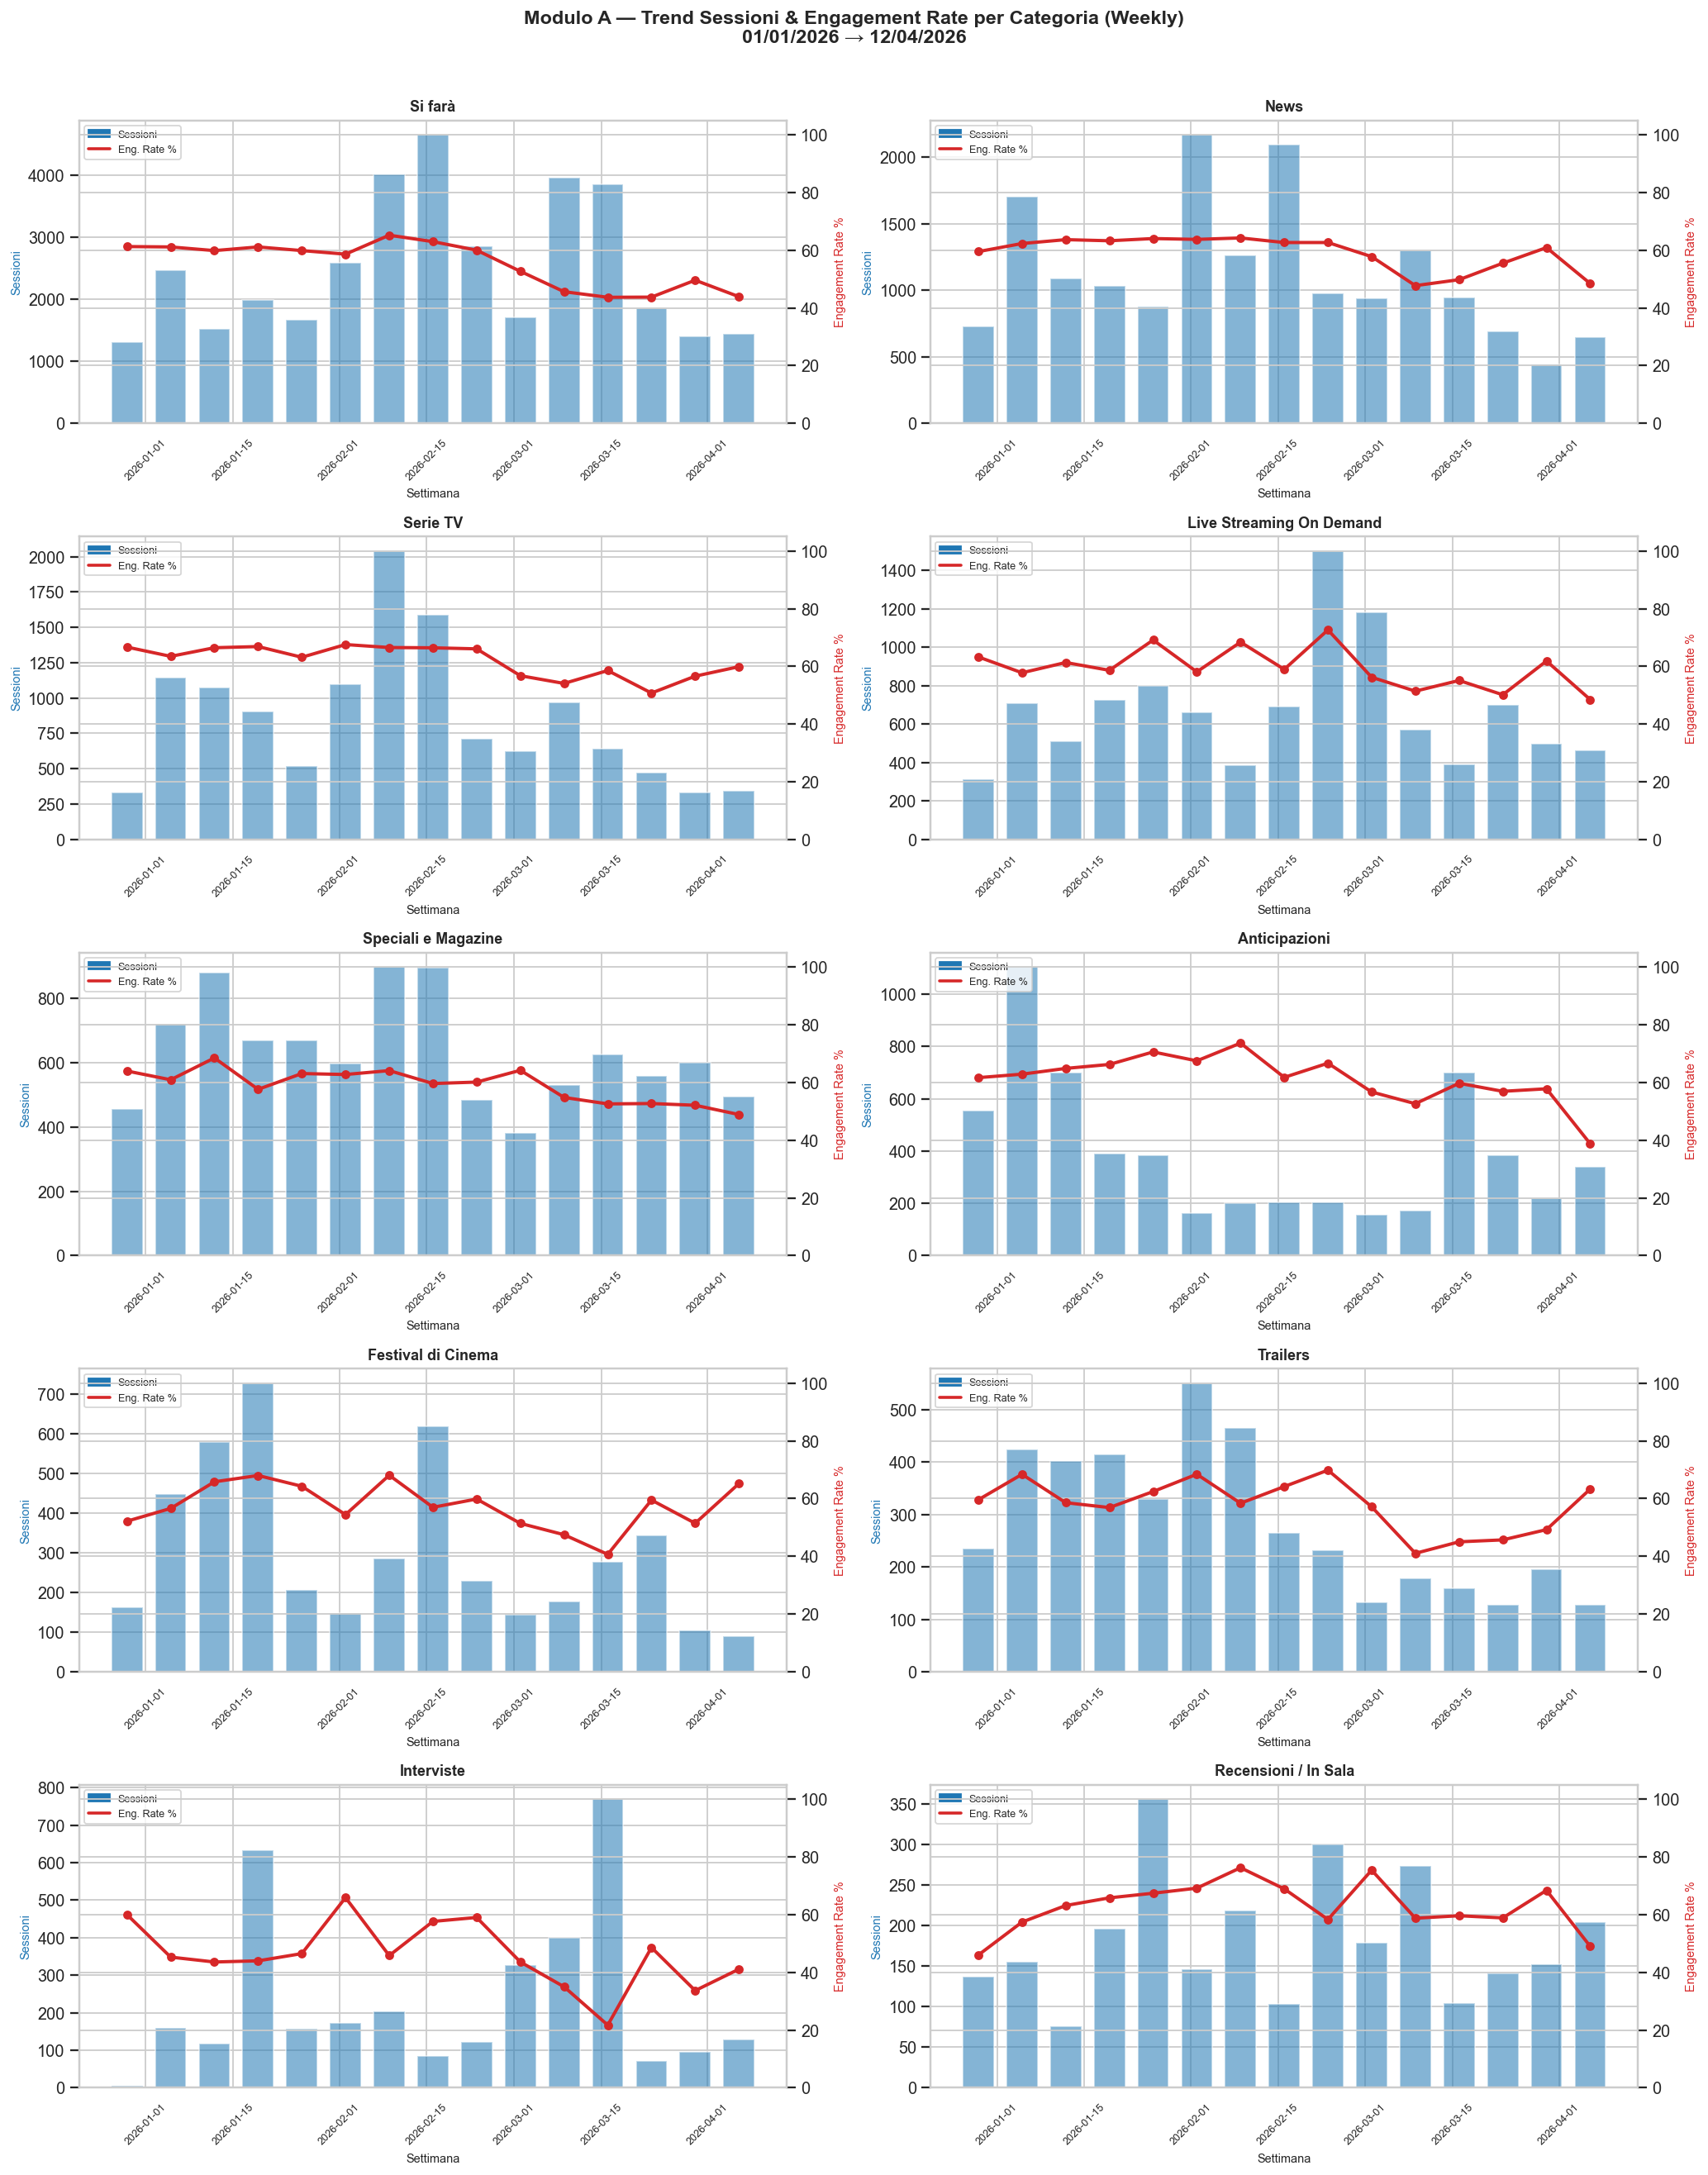

In [6]:
n_cats = len(top_cats)
n_cols = 2
n_rows = (n_cats + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

COLOR_SESSIONS = '#1f77b4'
COLOR_ER       = '#d62728'

for i, cat in enumerate(top_cats):
    cat_data = agg_df[agg_df['category'] == cat].sort_values('period')
    ax1 = axes[i]
    ax2 = ax1.twinx()

    ax1.bar(cat_data['period'], cat_data['sessions'],
            color=COLOR_SESSIONS, alpha=0.55, width=5 if GRANULARITY == 'Weekly' else 0.8, label='Sessioni')
    ax2.plot(cat_data['period'], cat_data['engagementRate'],
             color=COLOR_ER, linewidth=2.2, marker='o', markersize=5, label='Eng. Rate %')

    ax1.set_title(cat, fontweight='bold', fontsize=10)
    ax1.set_xlabel(time_label, fontsize=8)
    ax1.set_ylabel('Sessioni', color=COLOR_SESSIONS, fontsize=8)
    ax2.set_ylabel('Engagement Rate %', color=COLOR_ER, fontsize=8)
    ax1.tick_params(axis='x', rotation=45, labelsize=7)
    ax2.set_ylim(0, 105)

    lines1 = [mpatches.Patch(color=COLOR_SESSIONS, label='Sessioni')]
    lines2 = [plt.Line2D([0], [0], color=COLOR_ER, linewidth=2, label='Eng. Rate %')]
    ax1.legend(handles=lines1 + lines2, fontsize=7, loc='upper left')

# Nasconde axes vuoti
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    f'Modulo A — Trend Sessioni & Engagement Rate per Categoria ({GRANULARITY})\n'
    f'{START_DATE.strftime("%d/%m/%Y")} → {END_DATE.strftime("%d/%m/%Y")}',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

In [7]:
# ── Tabella riassuntiva per categoria ────────────────────────
summary = agg_df.groupby('category').agg(
    tot_sessions=('sessions', 'sum'),
    tot_pv=('screenPageViews', 'sum'),
    avg_engagement_rate=('engagementRate', 'mean'),
    avg_session_duration_s=('averageSessionDuration', 'mean'),
    avg_bounce_rate=('bounceRate', 'mean'),
).sort_values('tot_pv', ascending=False)

summary['avg_engagement_rate'] = summary['avg_engagement_rate'].round(1)
summary['avg_session_duration_s'] = summary['avg_session_duration_s'].round(0).astype(int)
summary['avg_bounce_rate'] = summary['avg_bounce_rate'].round(3)

print("\n📊 RIEPILOGO PER CATEGORIA")
print(summary.to_string())
summary


📊 RIEPILOGO PER CATEGORIA
                          tot_sessions  tot_pv  avg_engagement_rate  avg_session_duration_s  avg_bounce_rate
category                                                                                                    
Si farà                          37293   37856                 55.3                      60            0.467
News                             16895   17559                 59.1                      79            0.421
Serie TV                         12806   13024                 62.0                      96            0.396
Live Streaming On Demand         10098   10500                 59.4                      90            0.408
Speciali e Magazine               9450    9688                 59.1                      98            0.418
Anticipazioni                     5871    5980                 61.2                      78            0.400
Festival di Cinema                4541    4928                 57.4                     106          

,tot_sessions,tot_pv,avg_engagement_rate,avg_session_duration_s,avg_bounce_rate
category,,,,,
Si farà,37293,37856,55.3,60,0.467
News,16895,17559,59.1,79,0.421
Serie TV,12806,13024,62.0,96,0.396
Live Streaming On Demand,10098,10500,59.4,90,0.408
Speciali e Magazine,9450,9688,59.1,98,0.418
Anticipazioni,5871,5980,61.2,78,0.400
Festival di Cinema,4541,4928,57.4,106,0.439
Trailers,4242,4373,57.9,88,0.434
Interviste,3446,3768,46.1,101,0.486


---
## Modulo B — Correlazione volume di pubblicazione / engagement
**Proxy per n. articoli pubblicati:** nuovi `pagePath` comparsi per la prima volta nel dataset in ciascun giorno.  
Calcola correlazioni di Pearson tra:
- `n_nuovi_articoli` ↔ `sessions`  
- `n_nuovi_articoli` ↔ `engagementRate`  
- `sessions` ↔ `engagementRate`

In [8]:
# ── Costruzione proxy: "prima apparizione" di un pagePath ────
df_sorted = df.sort_values('date_parsed')
first_appearance = df_sorted.groupby('pagePath')['date_parsed'].min().reset_index()
first_appearance.columns = ['pagePath', 'first_date']

new_articles_daily = (
    first_appearance.groupby('first_date').size()
    .reset_index(name='n_new_articles')
)

# Metriche aggregate a livello giornaliero (tutte le categorie)
daily_totals = df.groupby('date_parsed').agg(
    sessions=('sessions', 'sum'),
    engagedSessions=('engagedSessions', 'sum'),
    screenPageViews=('screenPageViews', 'sum'),
).reset_index()
daily_totals['engagementRate'] = (
    daily_totals['engagedSessions'] / daily_totals['sessions'].replace(0, np.nan) * 100
).round(2)

# Join
corr_df = daily_totals.merge(new_articles_daily, left_on='date_parsed', right_on='first_date', how='left')
corr_df['n_new_articles'] = corr_df['n_new_articles'].fillna(0)

print(f"✓ Daily data for correlation: {len(corr_df)} giorni")
corr_df.head()

✓ Daily data for correlation: 102 giorni


,date_parsed,sessions,engagedSessions,screenPageViews,engagementRate,first_date,n_new_articles
0,2026-01-01,812,505,827,62.19,2026-01-01,81
1,2026-01-02,1105,655,1143,59.28,2026-01-02,50
2,2026-01-03,1173,704,1193,60.02,2026-01-03,29
3,2026-01-04,1404,857,1435,61.04,2026-01-04,28
4,2026-01-05,1726,1074,1794,62.22,2026-01-05,38


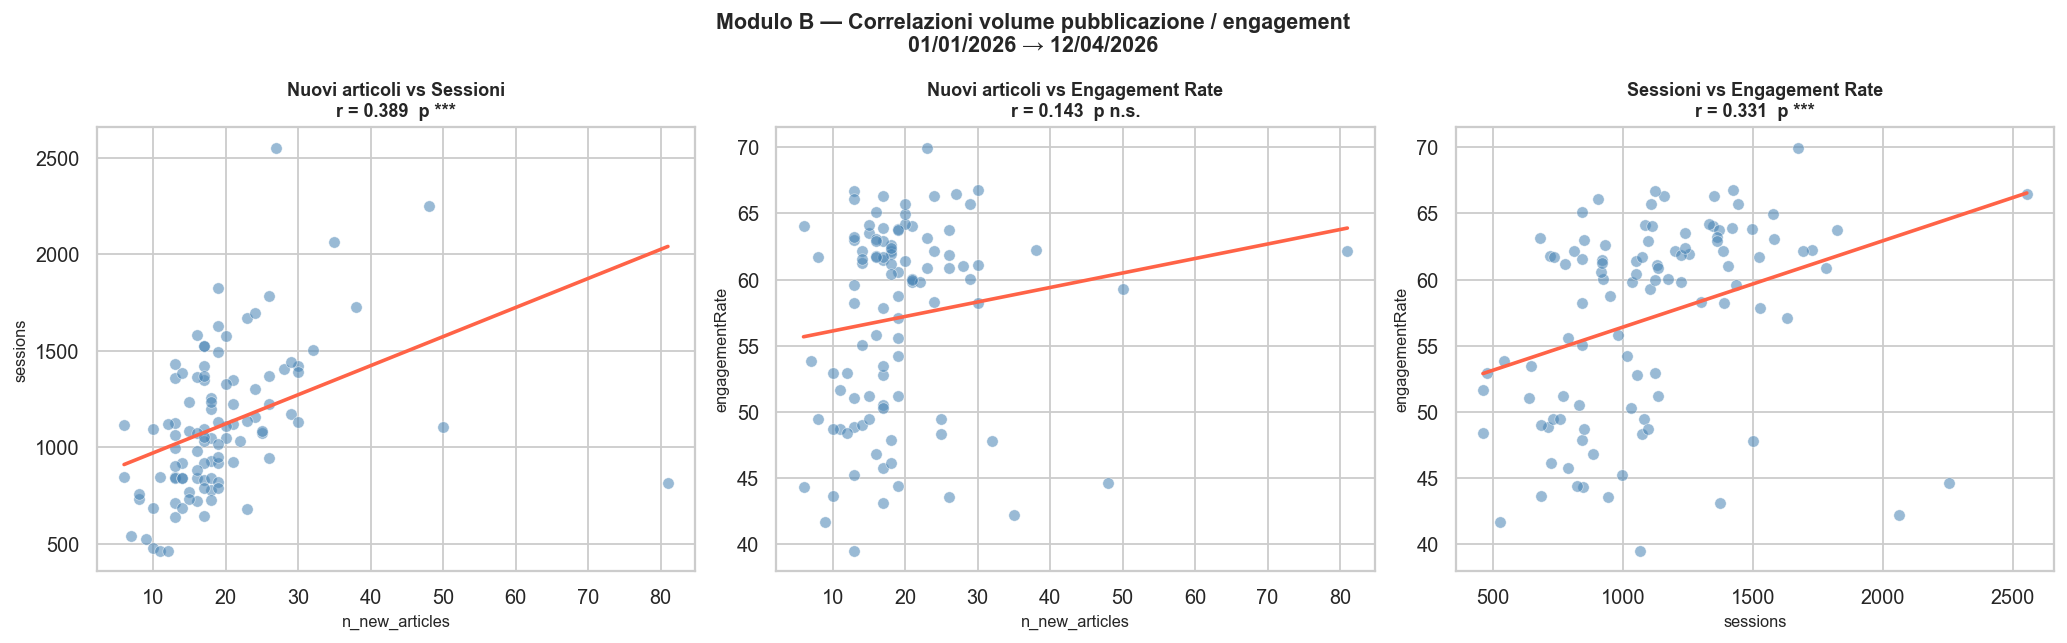


📋 INTERPRETAZIONE:
  Nuovi articoli vs Sessioni: r=0.389 — correlazione positiva moderata (p=0.0001)
  Nuovi articoli vs Engagement Rate: r=0.143 — correlazione positiva debole (p=0.1503)
  Sessioni vs Engagement Rate: r=0.331 — correlazione positiva moderata (p=0.0007)


In [9]:
pairs = [
    ('n_new_articles', 'sessions',       'Nuovi articoli vs Sessioni'),
    ('n_new_articles', 'engagementRate',  'Nuovi articoli vs Engagement Rate'),
    ('sessions',       'engagementRate',  'Sessioni vs Engagement Rate'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (x_col, y_col, title) in zip(axes, pairs):
    valid = corr_df[[x_col, y_col]].dropna()
    r, p = stats.pearsonr(valid[x_col], valid[y_col])

    ax.scatter(valid[x_col], valid[y_col], alpha=0.55, s=40, color='steelblue', edgecolors='white', linewidth=0.4)

    # Regressione
    m, b = np.polyfit(valid[x_col], valid[y_col], 1)
    x_line = np.linspace(valid[x_col].min(), valid[x_col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2)

    significance = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    ax.set_title(f'{title}\nr = {r:.3f}  p {significance}', fontweight='bold', fontsize=10)
    ax.set_xlabel(x_col, fontsize=9)
    ax.set_ylabel(y_col, fontsize=9)

fig.suptitle(
    f'Modulo B — Correlazioni volume pubblicazione / engagement\n'
    f'{START_DATE.strftime("%d/%m/%Y")} → {END_DATE.strftime("%d/%m/%Y")}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\n📋 INTERPRETAZIONE:")
for x_col, y_col, title in pairs:
    valid = corr_df[[x_col, y_col]].dropna()
    r, p = stats.pearsonr(valid[x_col], valid[y_col])
    direction = "positiva" if r > 0 else "negativa"
    strength = "forte" if abs(r) > 0.6 else ("moderata" if abs(r) > 0.3 else "debole")
    print(f"  {title}: r={r:.3f} — correlazione {direction} {strength} (p={p:.4f})")

📊 CORRELAZIONI sessions ↔ engagementRate PER CATEGORIA

               categoria      r  p_value  n_periodi
              Interviste -0.250   0.0242         81
    Recensioni / In Sala -0.105   0.3100         96
           Anticipazioni -0.036   0.7281         98
                   Altro -0.035   0.7370         93
                Rubriche -0.026   0.8694         41
              Animazione  0.048   0.8712         14
      Festival di Cinema  0.088   0.4073         90
                 Si farà  0.112   0.2632        102
              Recensioni  0.152   0.1670         84
                    News  0.193   0.0518        102
Live Streaming On Demand  0.204   0.0402        102
     Speciali e Magazine  0.205   0.0388        102
             Cult Movies  0.218   0.4184         16
                Serie TV  0.236   0.0171        102
                Trailers  0.299   0.0024        101
  Guide e Film da Vedere  0.324   0.1753         19


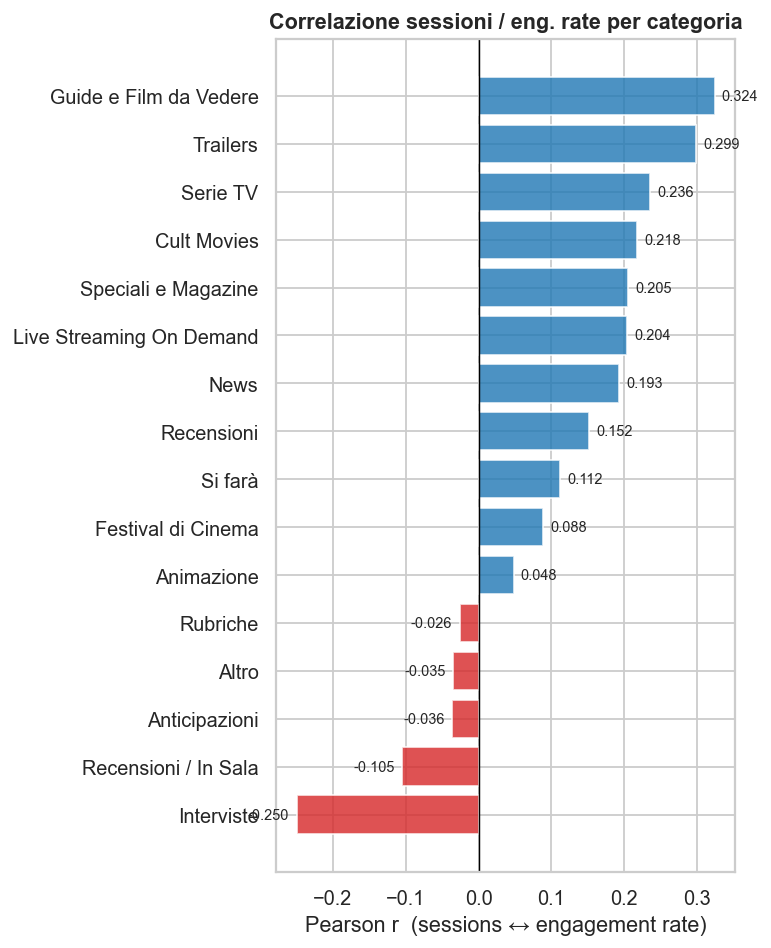

In [10]:
# ── Correlazioni per singola categoria ───────────────────────
print("📊 CORRELAZIONI sessions ↔ engagementRate PER CATEGORIA\n")
corr_rows = []
for cat in sorted(df['category'].unique()):
    cat_daily = df[df['category'] == cat].groupby('date_parsed').agg(
        sessions=('sessions', 'sum'),
        engagedSessions=('engagedSessions', 'sum'),
    ).reset_index()
    cat_daily['engagementRate'] = (cat_daily['engagedSessions'] / cat_daily['sessions'].replace(0, np.nan) * 100)
    valid = cat_daily[['sessions', 'engagementRate']].dropna()
    if len(valid) < 5:
        continue
    r, p = stats.pearsonr(valid['sessions'], valid['engagementRate'])
    corr_rows.append({'categoria': cat, 'r': round(r, 3), 'p_value': round(p, 4), 'n_periodi': len(valid)})

corr_by_cat = pd.DataFrame(corr_rows).sort_values('r')
print(corr_by_cat.to_string(index=False))

# Heatmap
fig, ax = plt.subplots(figsize=(6, max(4, len(corr_by_cat) * 0.4 + 1)))
colors = ['#d62728' if r < 0 else '#1f77b4' for r in corr_by_cat['r']]
bars = ax.barh(corr_by_cat['categoria'], corr_by_cat['r'], color=colors, alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Pearson r  (sessions ↔ engagement rate)")
ax.set_title("Correlazione sessioni / eng. rate per categoria", fontweight='bold')
for bar, r in zip(bars, corr_by_cat['r']):
    ax.text(bar.get_width() + (0.01 if r >= 0 else -0.01), bar.get_y() + bar.get_height() / 2,
            f'{r:.3f}', va='center', ha='left' if r >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.show()

---
## Modulo C — Segmentazione per canale di provenienza
`sessionDefaultChannelGroup` → engagement rate medio per canale e categoria.  
Regola: prima di concludere su problemi editoriali, verifica che il calo non sia dovuto a un cambio nel **mix di canali**.

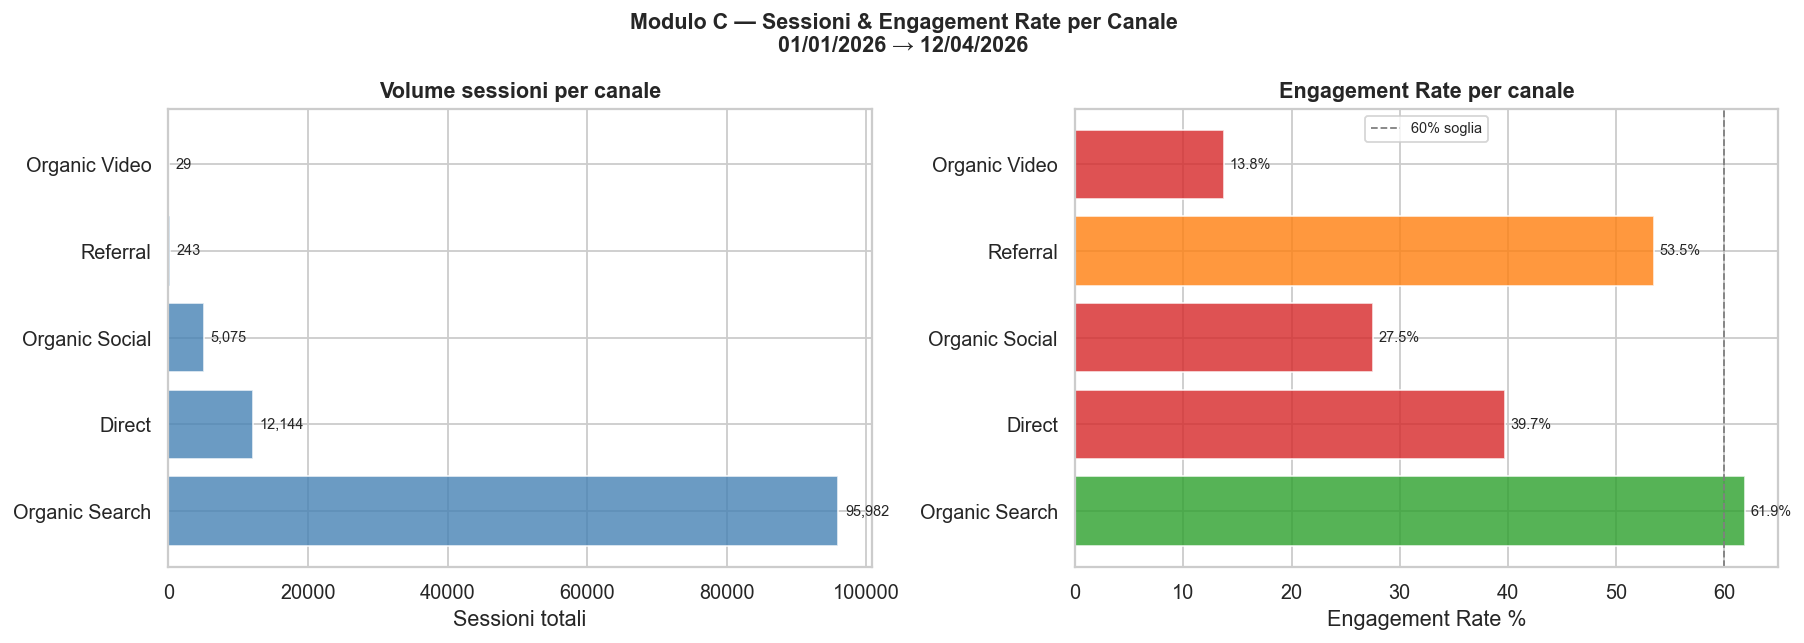


📋 Dettaglio canali:
sessionDefaultChannelGroup  sessions  engagementRate
            Organic Search     95982            61.9
                    Direct     12144            39.7
            Organic Social      5075            27.5
                  Referral       243            53.5
             Organic Video        29            13.8


In [11]:
# ── Engagement rate per canale ───────────────────────────────
channel_agg = df.groupby('sessionDefaultChannelGroup').agg(
    sessions=('sessions', 'sum'),
    engagedSessions=('engagedSessions', 'sum'),
    screenPageViews=('screenPageViews', 'sum'),
).reset_index()
channel_agg['engagementRate'] = (
    channel_agg['engagedSessions'] / channel_agg['sessions'].replace(0, np.nan) * 100
).round(1)
channel_agg = channel_agg.sort_values('sessions', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: sessioni per canale
axes[0].barh(channel_agg['sessionDefaultChannelGroup'], channel_agg['sessions'],
             color='steelblue', alpha=0.8)
axes[0].set_xlabel('Sessioni totali')
axes[0].set_title('Volume sessioni per canale', fontweight='bold')
for bar, val in zip(axes[0].patches, channel_agg['sessions']):
    axes[0].text(bar.get_width() + channel_agg['sessions'].max() * 0.01,
                 bar.get_y() + bar.get_height() / 2, f'{val:,.0f}', va='center', fontsize=8)

# Grafico 2: engagement rate per canale
colors_er = ['#2ca02c' if v >= 60 else ('#ff7f0e' if v >= 40 else '#d62728')
             for v in channel_agg['engagementRate']]
axes[1].barh(channel_agg['sessionDefaultChannelGroup'], channel_agg['engagementRate'],
             color=colors_er, alpha=0.8)
axes[1].set_xlabel('Engagement Rate %')
axes[1].set_title('Engagement Rate per canale', fontweight='bold')
axes[1].axvline(60, color='gray', linestyle='--', linewidth=1, label='60% soglia')
axes[1].legend(fontsize=8)
for bar, val in zip(axes[1].patches, channel_agg['engagementRate']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f'{val:.1f}%', va='center', fontsize=8)

fig.suptitle(
    f'Modulo C — Sessioni & Engagement Rate per Canale\n'
    f'{START_DATE.strftime("%d/%m/%Y")} → {END_DATE.strftime("%d/%m/%Y")}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("\n📋 Dettaglio canali:")
print(channel_agg[['sessionDefaultChannelGroup', 'sessions', 'engagementRate']].to_string(index=False))

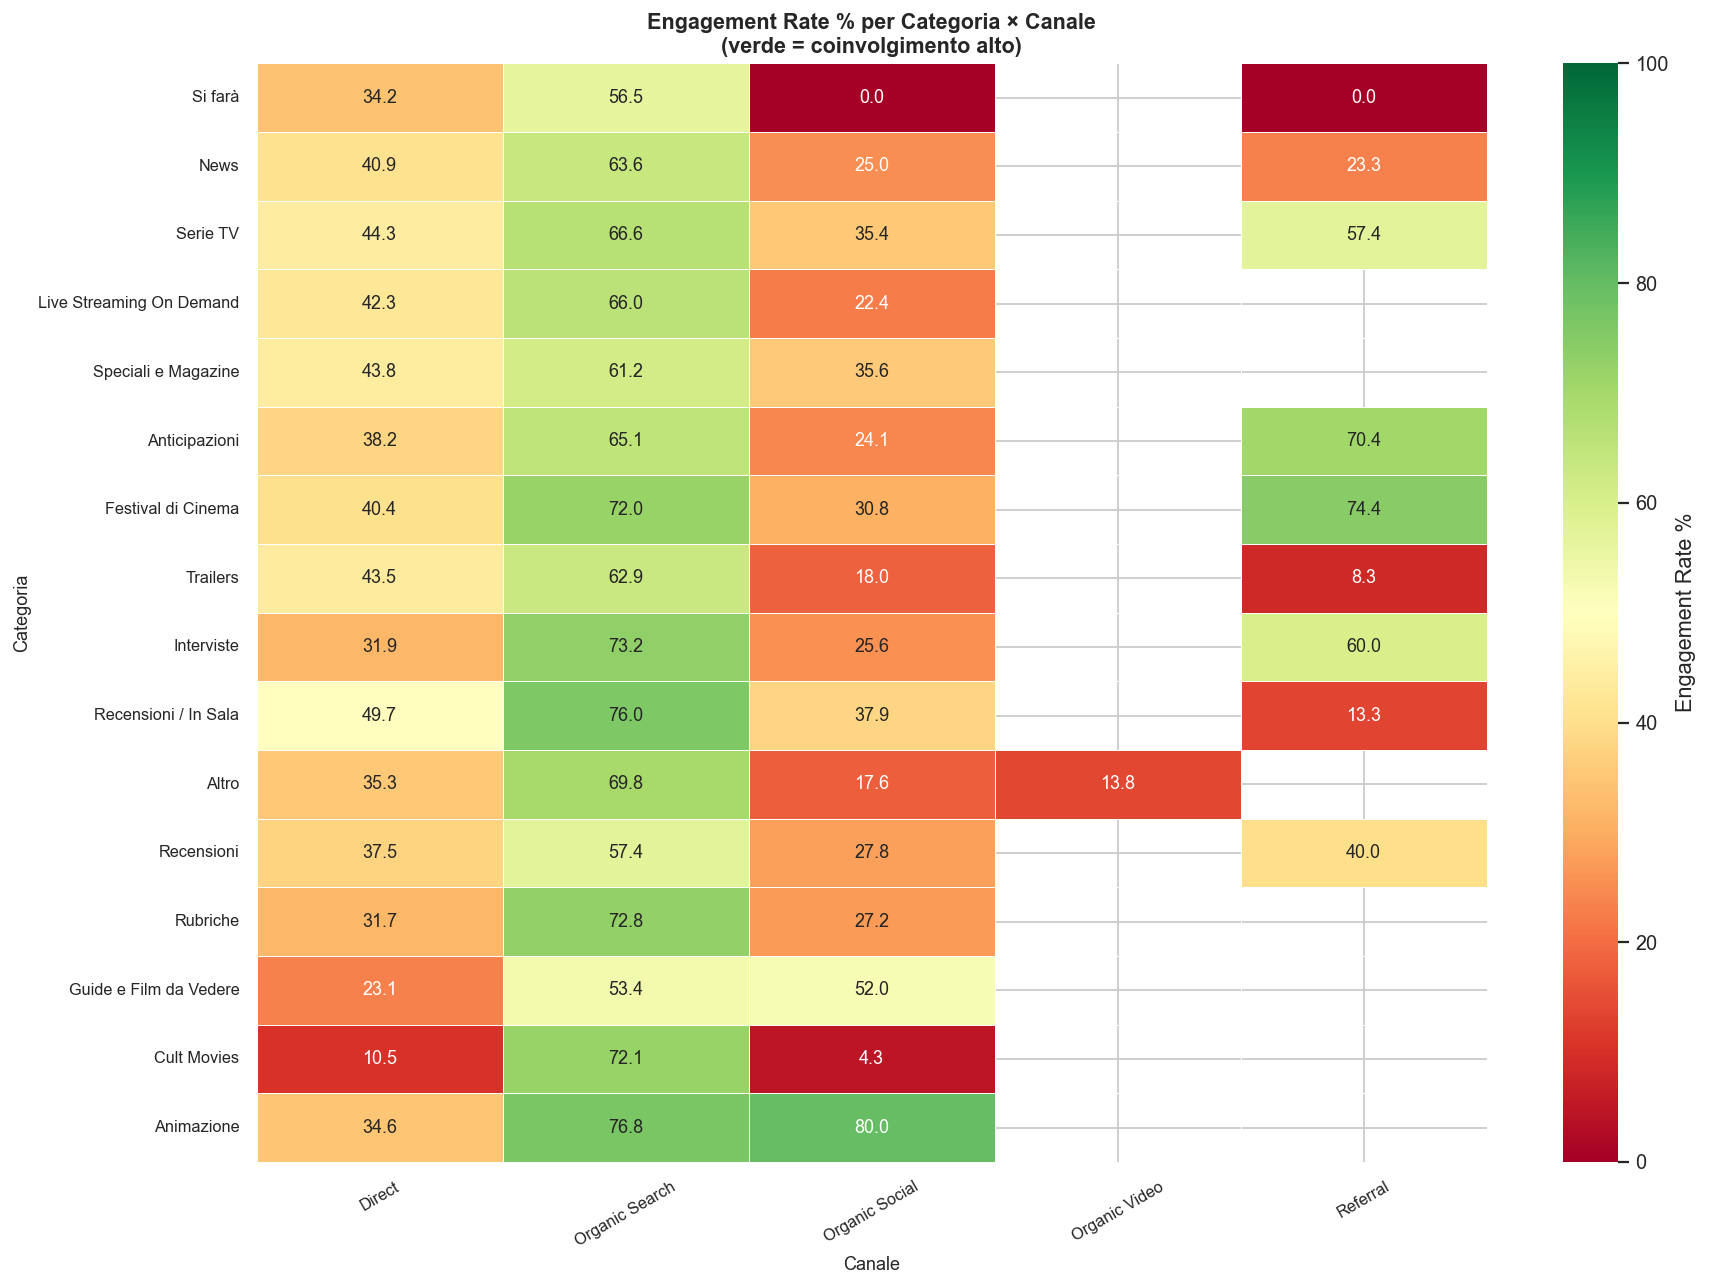

In [12]:
# ── Heatmap: engagement rate per categoria × canale ──────────
pivot_er = df.groupby(['category', 'sessionDefaultChannelGroup']).agg(
    sessions=('sessions', 'sum'),
    engagedSessions=('engagedSessions', 'sum'),
).reset_index()
pivot_er['engagementRate'] = (
    pivot_er['engagedSessions'] / pivot_er['sessions'].replace(0, np.nan) * 100
).round(1)

# Filtra canali con almeno 100 sessioni totali
top_channels = (
    pivot_er.groupby('sessionDefaultChannelGroup')['sessions'].sum()
    .nlargest(8).index.tolist()
)
pivot_er_filtered = pivot_er[pivot_er['sessionDefaultChannelGroup'].isin(top_channels)]

heatmap_data = pivot_er_filtered.pivot_table(
    index='category', columns='sessionDefaultChannelGroup',
    values='engagementRate', aggfunc='mean'
).reindex(index=summary.index)  # ordina per PV decrescenti

fig, ax = plt.subplots(figsize=(14, max(6, len(heatmap_data) * 0.5 + 2)))
sns.heatmap(
    heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=0, vmax=100, linewidths=0.4, ax=ax,
    cbar_kws={'label': 'Engagement Rate %'}
)
ax.set_title(
    'Engagement Rate % per Categoria × Canale\n(verde = coinvolgimento alto)',
    fontweight='bold', fontsize=12
)
ax.set_xlabel('Canale', fontsize=10)
ax.set_ylabel('Categoria', fontsize=10)
ax.tick_params(axis='x', rotation=30, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)
plt.tight_layout()
plt.show()

---
## Layer 3 — Content Performance Matrix
Classifica ogni categoria in uno dei quattro quadranti:

| Quadrante | Traffico | Engagement | Azione consigliata |
|-----------|----------|------------|---------------------|
| **Star** | Alto | Alto | Proteggi e replica |
| **Problema** | Alto | Basso | Scala qualità |
| **Niche** | Basso | Alto | Scala traffico |
| **Abbandona / Riformula** | Basso | Basso | Riformula o riduci |

**Soglia:** mediana di sessioni e engagement rate sul totale delle categorie.

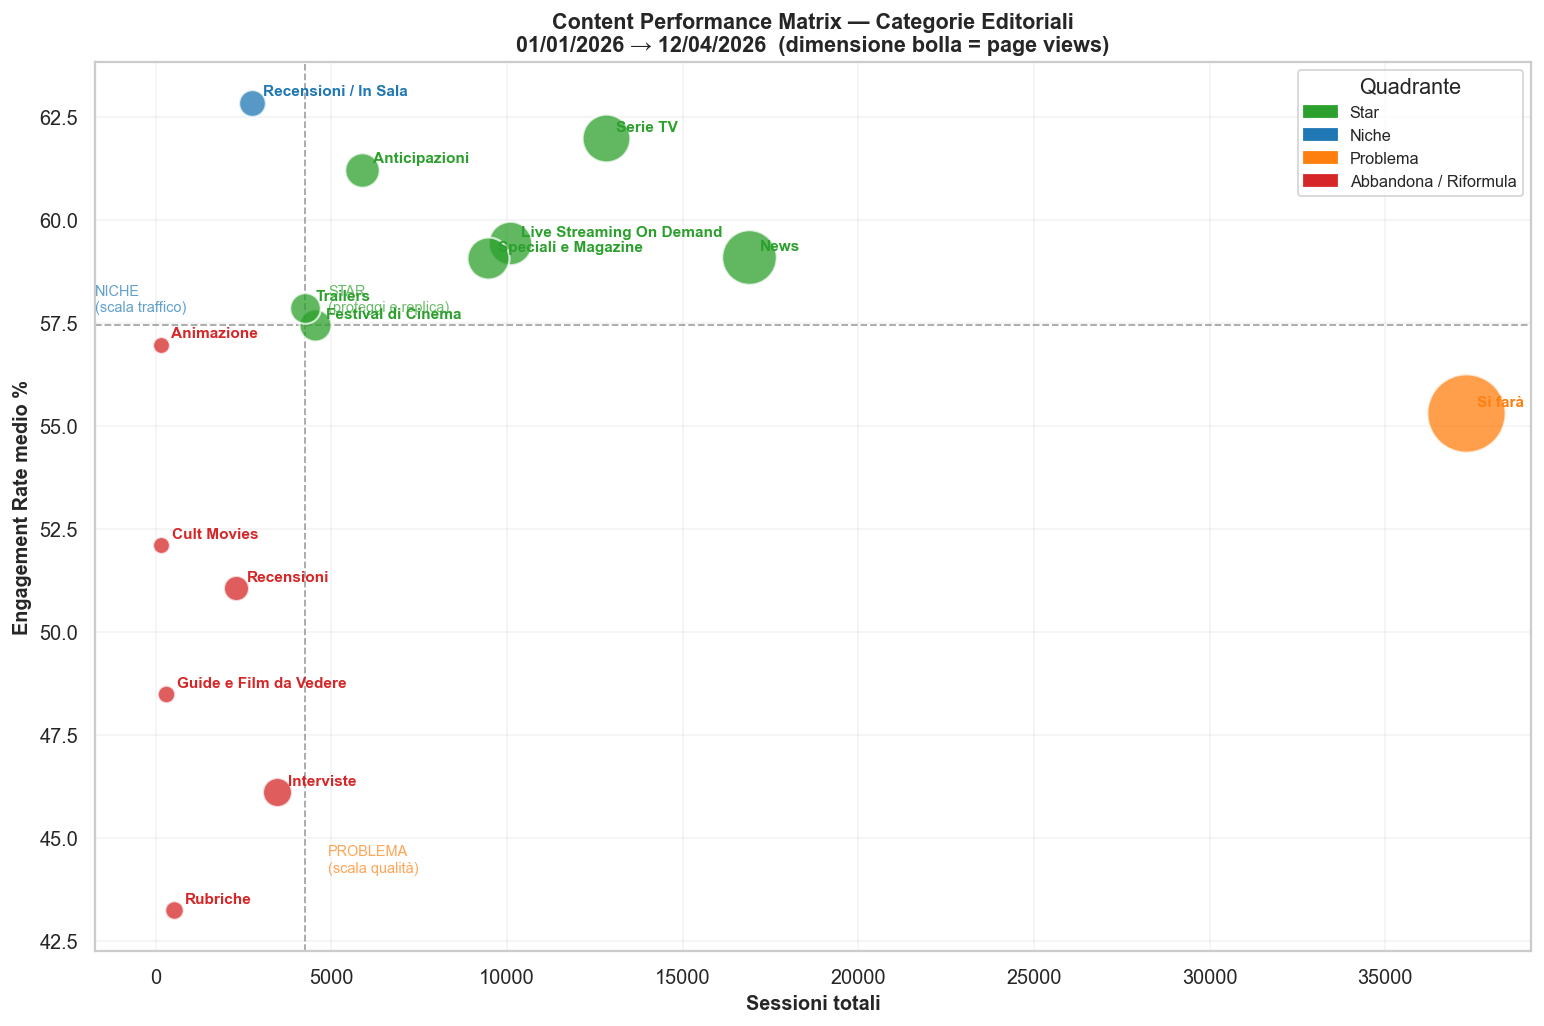


📊 POSIZIONAMENTO CATEGORIE:
                category              quadrant  tot_sessions  avg_engagement_rate  tot_pv
              Animazione Abbandona / Riformula           139            56.964286     154
             Cult Movies Abbandona / Riformula           165            52.095000     168
  Guide e Film da Vedere Abbandona / Riformula           287            48.473333     305
              Interviste Abbandona / Riformula          3446            46.096000    3768
              Recensioni Abbandona / Riformula          2280            51.063333    2394
                Rubriche Abbandona / Riformula           513            43.235000     535
    Recensioni / In Sala                 Niche          2742            62.841333    2941
                 Si farà              Problema         37293            55.294667   37856
           Anticipazioni                  Star          5871            61.216000    5980
      Festival di Cinema                  Star          4541           

In [13]:
# ── Dati per la matrice ──────────────────────────────────────
matrix_df = agg_df.groupby('category').agg(
    tot_sessions=('sessions', 'sum'),
    avg_engagement_rate=('engagementRate', 'mean'),
    tot_pv=('screenPageViews', 'sum'),
).reset_index()
matrix_df = matrix_df[matrix_df['category'] != 'Altro']  # esclude "Altro" dal posizionamento

# Soglie: mediana
sess_median = matrix_df['tot_sessions'].median()
er_median   = matrix_df['avg_engagement_rate'].median()

def assign_quadrant(row):
    high_traffic = row['tot_sessions'] >= sess_median
    high_er      = row['avg_engagement_rate'] >= er_median
    if high_traffic and high_er:
        return 'Star'
    elif high_traffic and not high_er:
        return 'Problema'
    elif not high_traffic and high_er:
        return 'Niche'
    else:
        return 'Abbandona / Riformula'

matrix_df['quadrant'] = matrix_df.apply(assign_quadrant, axis=1)

QUADRANT_COLORS = {
    'Star':                   '#2ca02c',
    'Niche':                  '#1f77b4',
    'Problema':               '#ff7f0e',
    'Abbandona / Riformula':  '#d62728',
}

fig, ax = plt.subplots(figsize=(12, 8))

for _, row in matrix_df.iterrows():
    color = QUADRANT_COLORS[row['quadrant']]
    # Dimensione bolla proporzionale ai page views
    size = (row['tot_pv'] / matrix_df['tot_pv'].max()) * 1800 + 80
    ax.scatter(row['tot_sessions'], row['avg_engagement_rate'],
               s=size, color=color, alpha=0.75, edgecolors='white', linewidth=1.2, zorder=3)
    ax.annotate(
        row['category'],
        (row['tot_sessions'], row['avg_engagement_rate']),
        textcoords='offset points', xytext=(6, 4),
        fontsize=8.5, color=color, fontweight='bold'
    )

# Linee soglia
ax.axvline(sess_median, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(er_median,   color='gray', linestyle='--', linewidth=1, alpha=0.7)

# Etichette quadranti
ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] != 0 else -100,
        er_median + (matrix_df['avg_engagement_rate'].max() - er_median) * 0.05,
        'NICHE\n(scala traffico)', color='#1f77b4', fontsize=8, alpha=0.7, va='bottom')
ax.text(sess_median + (matrix_df['tot_sessions'].max() - sess_median) * 0.02,
        er_median + (matrix_df['avg_engagement_rate'].max() - er_median) * 0.05,
        'STAR\n(proteggi e replica)', color='#2ca02c', fontsize=8, alpha=0.7, va='bottom')
ax.text(sess_median + (matrix_df['tot_sessions'].max() - sess_median) * 0.02,
        matrix_df['avg_engagement_rate'].min() * 1.02,
        'PROBLEMA\n(scala qualità)', color='#ff7f0e', fontsize=8, alpha=0.7, va='bottom')

# Legenda dimensione bolla
legend_patches = [mpatches.Patch(color=c, label=q) for q, c in QUADRANT_COLORS.items()]
ax.legend(handles=legend_patches, loc='upper right', fontsize=9, title='Quadrante')

ax.set_xlabel('Sessioni totali', fontweight='bold', fontsize=11)
ax.set_ylabel('Engagement Rate medio %', fontweight='bold', fontsize=11)
ax.set_title(
    f'Content Performance Matrix — Categorie Editoriali\n'
    f'{START_DATE.strftime("%d/%m/%Y")} → {END_DATE.strftime("%d/%m/%Y")}  '
    f'(dimensione bolla = page views)',
    fontweight='bold', fontsize=12
)
ax.grid(alpha=0.2, zorder=0)
plt.tight_layout()
plt.show()

print("\n📊 POSIZIONAMENTO CATEGORIE:")
print(matrix_df[['category', 'quadrant', 'tot_sessions', 'avg_engagement_rate', 'tot_pv']]
      .sort_values('quadrant').to_string(index=False))

---
## Export risultati
Salva la Content Performance Matrix e il riepilogo per categoria in Excel.

In [14]:
from pathlib import Path

output_dir = Path(_PROJECT_ROOT) / 'output'
output_dir.mkdir(exist_ok=True)

ts = f"{START_DATE.strftime('%Y%m%d')}_{END_DATE.strftime('%Y%m%d')}"
out_path = output_dir / f"traffic_engagement_analysis_{ts}.xlsx"

with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    summary.reset_index().to_excel(writer, sheet_name='Riepilogo_Categorie', index=False)
    matrix_df.to_excel(writer, sheet_name='Content_Performance_Matrix', index=False)
    channel_agg.to_excel(writer, sheet_name='Engagement_per_Canale', index=False)
    corr_by_cat.to_excel(writer, sheet_name='Correlazioni_Categoria', index=False)
    agg_df.to_excel(writer, sheet_name='Dati_Aggregati', index=False)

print(f"✓ Export salvato in: {out_path}")

✓ Export salvato in: c:\Users\manuel.deluzi\OneDrive - Havas\Projects\personali\taxi_drivers\output\traffic_engagement_analysis_20260101_20260412.xlsx
